![image.png](https://i.imgur.com/a3uAqnb.png)

# **🏭 Exercise: Steel Defect Classification with Pretrained Model (EfficientNet)**

> **Your turn!** Yesterday you trained a CNN from scratch on the NEU steel defect dataset. Today let's see what **transfer learning** can do on the *same* dataset.

In this exercise, we will:

✅ Build a **Dataset** for the **NEU Steel Defects dataset** (6 defect classes)  
✅ Use a **pretrained EfficientNet-B0 model** for classification  
✅ Train and evaluate the model using **three different fine-tuning strategies**  
✅ Compare the results to the simple CNN you built yesterday — was the effort worth it?


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import kagglehub
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Download the dataset
path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")
path


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1'

In [ ]:
# The downloaded folder contains a top-level "NEU-DET" folder
DATA_DIR = os.path.join(path, "NEU-DET")
print("Contents of DATA_DIR:", os.listdir(DATA_DIR))
print("Train classes:", os.listdir(os.path.join(DATA_DIR, 'train', 'images')))


Contents of DATA_DIR: ['validation', 'train']
Train classes: ['rolled-in_scale', 'scratches', 'pitted_surface', 'crazing', 'patches', 'inclusion']


## 1️⃣ Dataset Class

Unlike the Cats & Dogs dataset (which used a CSV), the NEU dataset is organized as **folders of images** — one folder per class. PyTorch's `ImageFolder` is built exactly for this layout, so we'll use it instead of writing our own `Dataset` class. ✨

```
NEU-DET/
├── train/images/
│   ├── crazing/      → image1.jpg, image2.jpg, ...
│   ├── inclusion/
│   ├── patches/
│   ├── pitted_surface/
│   ├── rolled-in_scale/
│   └── scratches/
└── validation/images/
    └── ... (same 6 folders)
```


In [ ]:
# Same transforms as the cats & dogs lab — ImageNet normalization is required
# because EfficientNet was pretrained on ImageNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # Flip images randomly
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # These random ahh values were found using ImageNet dataset, https://paperswithcode.com/dataset/imagenet
                          std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])


# Create dataset objects using ImageFolder
train_dataset = ImageFolder(root=os.path.join(DATA_DIR, 'train', 'images'),      transform=transform)
valid_dataset = ImageFolder(root=os.path.join(DATA_DIR, 'validation', 'images'), transform=test_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True,  num_workers=2)   # shuffle=True so the preview batch is mixed across classes

# Class names come from folder names
classes = train_dataset.classes
num_classes = len(classes)
print(f"Train: {len(train_dataset)} samples, Val: {len(valid_dataset)} samples")
print(f"Classes ({num_classes}): {classes}")

# Check a batch of images
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Labels: {labels}")


Train: 1440 samples, Val: 360 samples
Classes (6): ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Batch shape: torch.Size([32, 3, 224, 224]), Labels: tensor([0, 5, 0, 1, 1, 0, 5, 3, 3, 4, 4, 0, 0, 0, 3, 4, 4, 4, 2, 3, 4, 1, 5, 4,
        1, 0, 3, 2, 3, 0, 5, 0])


#### In the transformation pipeline, we use **specific mean and standard deviation values**

## **🔹 Where Do These Values Come From?**
✅ These values were found using the **ImageNet dataset**, a large-scale dataset used for training **pretrained models** like ResNet, EfficientNet, and VGG.  
✅ **Reference**: [ImageNet Dataset](https://paperswithcode.com/dataset/imagenet)  

## **🔹 Why Do We Use Them?**
1️⃣ **Pretrained Models Expect These Values**  
   - If a model was trained using a certain mean & std, we should use the **same values** for inference/training.
   - This ensures the input distribution matches what the model was trained on.
   - We are finetuning an EfficientNet here, which was pretrained on Imagenet, so will use these values.

🤔 **Think about it:** ImageNet contains photos of cats, dogs, planes, cars... NOT steel surfaces. Will a model pretrained on it still help us? You'll find out below 👀


### Let's display some images

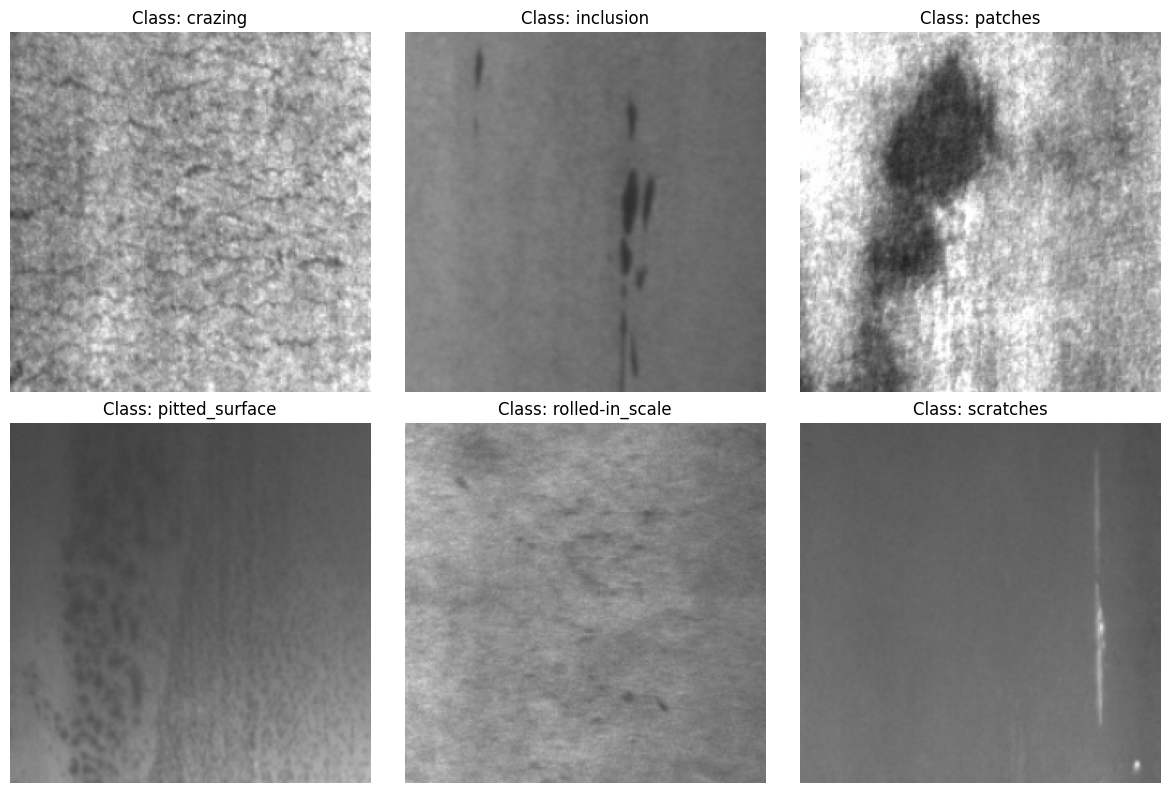

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define mean & std for denormalization (EfficientNet preprocessing)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Display 6 images — one from each class so you see all defect types
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Find one image index per class
seen = {}
for idx, (_, label) in enumerate(train_dataset.samples):
    if label not in seen:
        seen[label] = idx
    if len(seen) == num_classes:
        break

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[seen[i]]   # Load image & label

    # Convert tensor to numpy for visualization
    img_np = img.numpy().transpose(1, 2, 0)  # (C, H, W) → (H, W, C)

    # Denormalize the image
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # Show image
    ax.imshow(img_np)
    ax.set_title(f'Class: {classes[label]}')
    ax.axis('off')

plt.tight_layout()
plt.show()


## 2️⃣ Model Class

#### Instead of training from scratch, we use **EfficientNet-B0** with a modified output layer.

Compared to the cats & dogs lab, the only change is the final layer — we now output **6 classes** instead of 1 (binary).


In [ ]:
from torchvision import models

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)

# Modify the classifier for 6-class classification (NEU defect types)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)  # 6 classes

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 230MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## 3️⃣ Training and Validation Loops

These loops are slightly different from yesterday's cats & dogs lab because we have **6 classes instead of 2**:

| | Cats & Dogs (binary) | NEU Defects (multi-class) |
|---|---|---|
| Loss | `BCEWithLogitsLoss` | `CrossEntropyLoss` |
| Output shape | `[batch, 1]` → squeeze | `[batch, 6]` → no squeeze |
| Predictions | `sigmoid(out) > 0.5` | `argmax(out)` |
| Labels dtype | `float` | `long` (default) |


In [ ]:
from tqdm import tqdm    # Shows progress bar

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)            # Shape: [batch_size, 6]
        loss = criterion(outputs, labels)  # CrossEntropyLoss handles softmax internally

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Track accuracy
        predictions = outputs.argmax(dim=1)  # Get class with highest score
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Compute accuracy
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


## 4️⃣ Running Training — Strategy 0: Train Everything

We start by training **all the parameters** — the pretrained weights are just a starting point. This usually gives the best accuracy but is slow and needs more data.


In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()                       # Multi-class classification
optimizer = optim.AdamW(model.parameters(), lr=0.001)
num_epochs = 10


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, valid_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")


100%|██████████| 45/45 [00:08<00:00,  5.12it/s]


Epoch 1/10: Train Loss=0.2462, Train Accuracy=93.12%, Val Loss=0.1420, Val Accuracy=95.56%


100%|██████████| 45/45 [00:07<00:00,  5.92it/s]


Epoch 2/10: Train Loss=0.1121, Train Accuracy=97.43%, Val Loss=0.0554, Val Accuracy=99.44%


100%|██████████| 45/45 [00:07<00:00,  6.15it/s]


...

Epoch 8/10: Train Loss=0.0463, Train Accuracy=98.54%, Val Loss=0.0080, Val Accuracy=99.72%


100%|██████████| 45/45 [00:07<00:00,  5.78it/s]


Epoch 9/10: Train Loss=0.0839, Train Accuracy=97.85%, Val Loss=0.0036, Val Accuracy=100.00%


100%|██████████| 45/45 [00:07<00:00,  5.88it/s]


Epoch 10/10: Train Loss=0.0386, Train Accuracy=99.10%, Val Loss=0.0007, Val Accuracy=100.00%


### Plot loss and some predictions

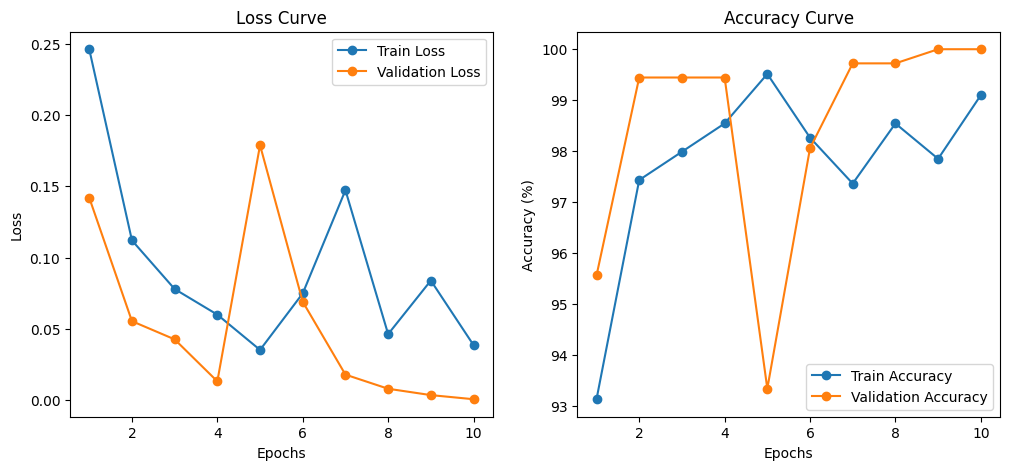

In [ ]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


## Strategy 1: Freeze Everything, Train Only Classifier Head

This is the **fastest** approach for transfer learning. The pretrained backbone acts as a fixed feature extractor, and you only train the final classification layer. Perfect for small datasets (few hundred images) or when you want quick results. Low risk of overfitting since you're only training ~1,000 parameters.

**When to use:** Small datasets, limited compute, quick experiments, or when your task is similar to ImageNet.

🤔 **Prediction time:** Steel defects don't really look like ImageNet photos... will this still work? Make a guess before running it. 👀


In [ ]:
# Train ONLY the classifier head (freeze entire backbone)
from torchvision import models
import torch.nn as nn
import torch

# Load pretrained model
model = models.efficientnet_b0(pretrained=True)

# Freeze ALL backbone layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head (this will be trainable by default)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, num_classes)  # 6 classes

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Verify what's trainable
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Training {trainable_params:,} / {total_params:,} parameters ({100*trainable_params/total_params:.2f}%)")


Training 7,686 / 4,015,234 parameters (0.19%)


In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)
num_epochs = 10


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, valid_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")


100%|██████████| 45/45 [00:03<00:00, 11.26it/s]


Epoch 1/10: Train Loss=0.8413, Train Accuracy=82.50%, Val Loss=0.4735, Val Accuracy=91.39%


100%|██████████| 45/45 [00:03<00:00, 12.21it/s]


Epoch 2/10: Train Loss=0.2835, Train Accuracy=95.56%, Val Loss=0.2838, Val Accuracy=94.44%


100%|██████████| 45/45 [00:04<00:00,  9.16it/s]


...

Epoch 8/10: Train Loss=0.0846, Train Accuracy=98.61%, Val Loss=0.1125, Val Accuracy=96.67%


100%|██████████| 45/45 [00:03<00:00, 11.98it/s]


Epoch 9/10: Train Loss=0.0847, Train Accuracy=98.06%, Val Loss=0.1379, Val Accuracy=96.11%


100%|██████████| 45/45 [00:04<00:00, 10.69it/s]


Epoch 10/10: Train Loss=0.0767, Train Accuracy=98.19%, Val Loss=0.1070, Val Accuracy=96.39%


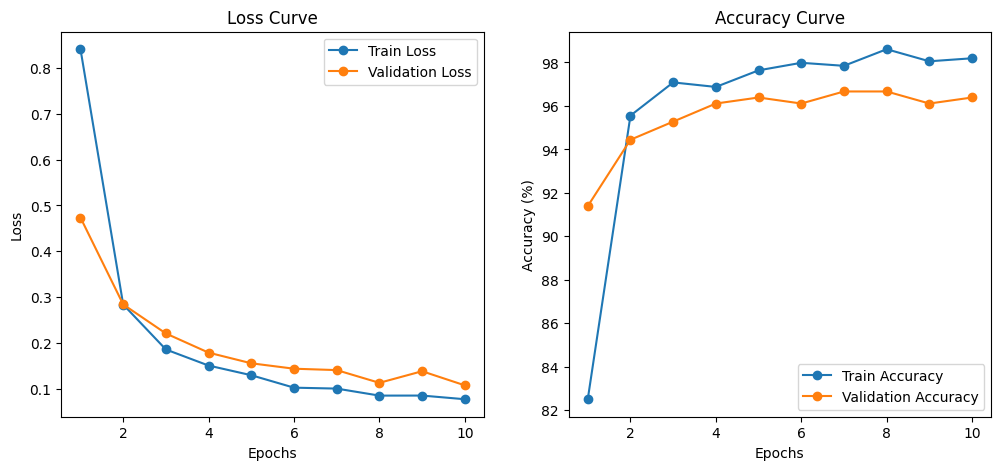

In [ ]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


## Strategy 2: Fine-Tune Last Layers + Classifier

This approach unfreezes the **last few blocks** of the backbone along with the classifier. The early layers (which learn generic features like edges) stay frozen, while later layers adapt to your specific task. This gives better accuracy than Strategy 1 but requires more data and longer training.

**When to use:** Medium datasets (1000+ images), when your domain differs from ImageNet, or when just training the classifier head doesn't give enough accuracy.

🏭 **Steel defects ≠ cats & dogs.** ImageNet's edge/texture detectors are still useful (early layers), but the higher-level "is this a face?" features are useless to us — so we let those late layers re-learn for our domain.


In [ ]:
# Let's check how many feature blocks we have
from torchvision import models

model = models.efficientnet_b0(pretrained=True)
print(f"Number of feature blocks: {len(model.features)}")
print(f"Total blocks: {len(model.features)}")


Number of feature blocks: 9
Total blocks: 9


In [ ]:
# Fine-tune last few layers + classifier (partial unfreezing)

from torchvision import models
import torch.nn as nn
import torch

# Load pretrained model
model = models.efficientnet_b0(pretrained=True)

# Freeze ALL layers first
for param in model.parameters():
    param.requires_grad = False


for param in model.features[7:].parameters():  # Last 2 blocks
    param.requires_grad = True

# Replace and unfreeze classifier
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, num_classes)  # 6 classes

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Verify what's trainable
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Training {trainable_params:,} / {total_params:,} parameters ({100*trainable_params/total_params:.2f}%)")


Training 1,137,078 / 4,015,234 parameters (28.32%)


In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)
num_epochs = 10


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, valid_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")


100%|██████████| 45/45 [00:04<00:00,  9.04it/s]


Epoch 1/10: Train Loss=0.3064, Train Accuracy=90.97%, Val Loss=0.0560, Val Accuracy=98.61%


100%|██████████| 45/45 [00:03<00:00, 11.64it/s]


Epoch 2/10: Train Loss=0.0432, Train Accuracy=98.68%, Val Loss=0.0266, Val Accuracy=99.17%


100%|██████████| 45/45 [00:06<00:00,  6.53it/s]


...

Epoch 8/10: Train Loss=0.0158, Train Accuracy=99.44%, Val Loss=0.0088, Val Accuracy=100.00%


100%|██████████| 45/45 [00:03<00:00, 11.55it/s]


Epoch 9/10: Train Loss=0.0056, Train Accuracy=99.93%, Val Loss=0.0073, Val Accuracy=99.72%


100%|██████████| 45/45 [00:04<00:00,  9.15it/s]


Epoch 10/10: Train Loss=0.0134, Train Accuracy=99.51%, Val Loss=0.0273, Val Accuracy=98.89%


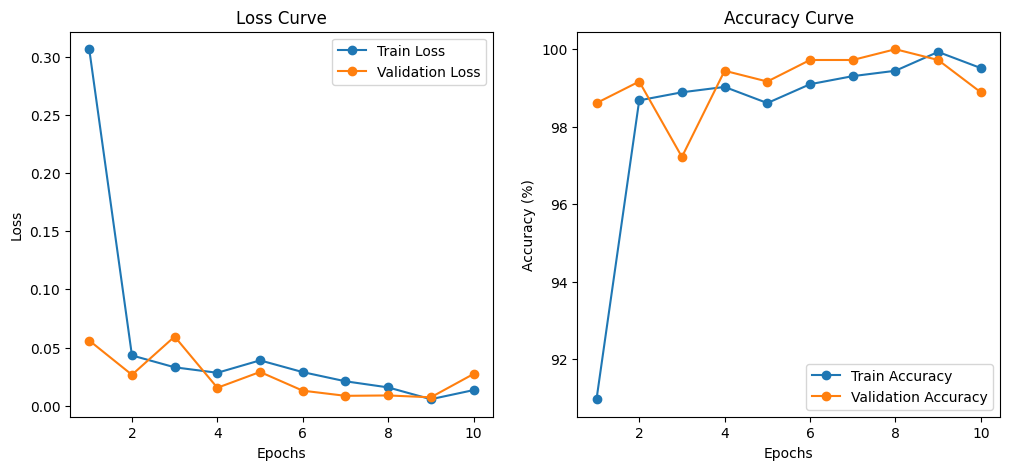

In [ ]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


## See Some Predictions

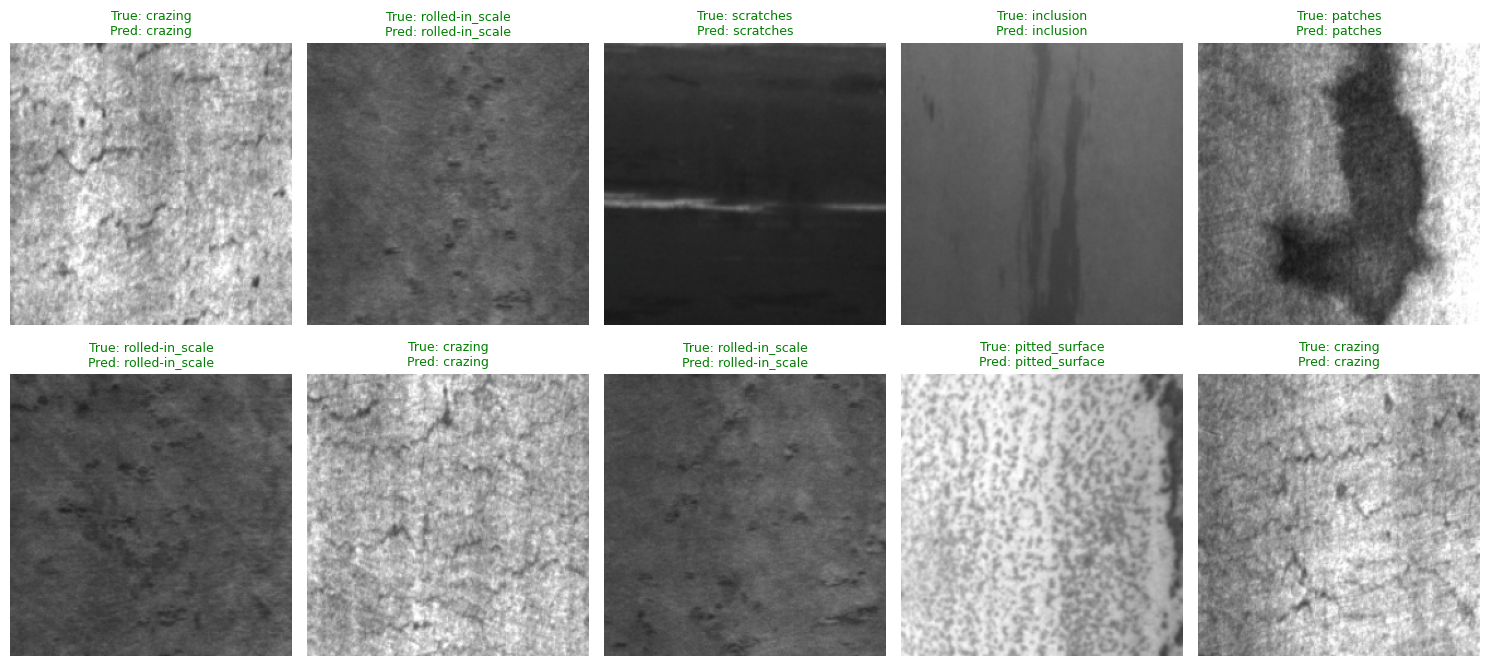

In [ ]:
# Function to display images with predicted labels
def show_predictions(model, dataloader, device):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

    # Denormalization
    mean_t = np.array([0.485, 0.456, 0.406])
    std_t  = np.array([0.229, 0.224, 0.225])

    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    for i, ax in enumerate(axes.flat):
        img_np = images[i].cpu().numpy().transpose(1, 2, 0)
        img_np = std_t * img_np + mean_t
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)
        true_label = classes[labels[i]]
        pred_label = classes[predictions[i]]
        color = "green" if true_label == pred_label else "red"
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(model, valid_loader, device)


# Very nice 🏭
Now you can detect steel defects at YASREF — same code, just better features.

![Defects beware](https://i.imgur.com/1r243HR.gif)


### Contributed by: Yazan Alshuaibi